In [3]:
import pandas as pd


In [4]:
df = pd.read_csv('data/dataset.csv')

In [5]:
df.columns

Index(['prompt', 'response', 'label'], dtype='str')

In [6]:
df.head()

,prompt,response,label
0,<|im_start|>system\r\nYou are a helpful assist...,An architect or engineer has a direct relation...,1.0
1,<|im_start|>system\r\nYou are a helpful assist...,Based on the information provided in the conte...,1.0
2,<|im_start|>system\r\nYou are a helpful assist...,"The ""appropriate"" (well defined), minimum effi...",1.0
3,<|im_start|>system\r\nYou are a helpful assist...,The name of the longest bridge in Germany is D...,1.0
4,<|im_start|>system\r\nYou are a helpful assist...,The present-day company that BankAmericard tur...,0.0


,response,label
count,689.000000,689.000000
mean,684.351234,0.701016
std,728.133175,0.458145
min,16.000000,0.000000
25%,145.000000,0.000000
50%,373.000000,1.000000
75%,923.000000,1.000000
max,2840.000000,1.000000


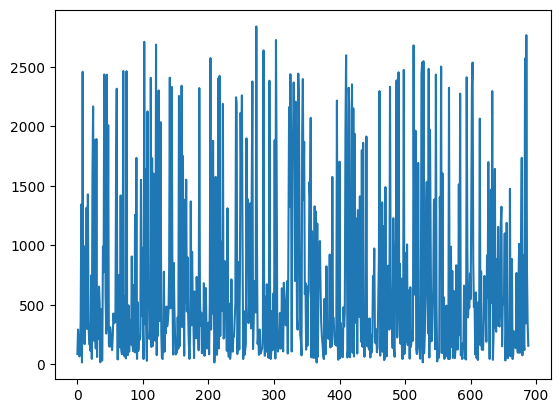

In [ ]:
df['response'] = df['response'].str.len()
df['response'].plot()
df.describe()

,prompt,response,label
count,689.000000,689.000000,689.000000
mean,1338.365747,684.351234,0.701016
std,326.471734,728.133175,0.458145
min,713.000000,16.000000,0.000000
25%,1114.000000,145.000000,0.000000
50%,1280.000000,373.000000,1.000000
75%,1484.000000,923.000000,1.000000
max,3278.000000,2840.000000,1.000000


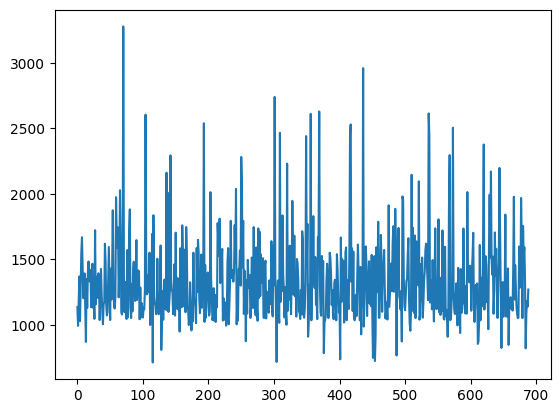

In [11]:
df['prompt'] = df['prompt'].str.len()
df['prompt'].plot()
df.describe()

In [1]:
import pandas as pd
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

df = pd.read_csv("data/dataset.csv")

df['total_tokens'] = [len(tokenizer.encode(p + r)) for p, r in zip(df['prompt'], df['response'])]

exceeded = (df['total_tokens'] > 512).sum()
print(f"All : {len(df)}")
print(f"Texts, over 512 tokens: {exceeded} ({(exceeded/len(df))*100:.1f}%)")
print(df['total_tokens'].describe())

c:\Coding\Python\SMILES-2026-Hallucination-Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All : 689
Texts, over 512 tokens: 152 (22.1%)
count     689.000000
mean      419.600871
std       182.987972
min       148.000000
25%       289.000000
50%       363.000000
75%       483.000000
max      1104.000000
Name: total_tokens, dtype: float64
